# VAE Portfolio Project - VAE Training

This notebook trains the Variational Autoencoder on portfolio returns.

In [20]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from data_loader import PortfolioDataLoader, create_train_test_split
from vae_model import VAE, VAETrainer
from utils import PortfolioConfig, normalize_data

plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

PyTorch version: 2.12.1
CUDA available: False
Device: cpu


## 1. Load and Prepare Data

In [21]:
# Load configuration
config = PortfolioConfig()

# Load returns data
returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)
print(f"Returns shape: {returns.shape}")
print(f"Returns columns: {returns.columns.tolist()}")

Returns shape: (2001, 4)
Returns columns: ['^GSPC', '^HSI', '^N225', '^STOXX50E']


In [22]:
# Normalize returns
returns_normalized, scaler = normalize_data(returns.values, fit=True)

print(f"Normalized returns shape: {returns_normalized.shape}")
print(f"Mean: {returns_normalized.mean():.6f}")
print(f"Std: {returns_normalized.std():.6f}")

Normalized returns shape: (2001, 4)
Mean: -0.000000
Std: 1.000000


In [23]:
# Train-test split
X_train, X_test = create_train_test_split(returns_normalized, test_size=0.2)

# Further split training into train and validation
X_train_split, X_val = create_train_test_split(X_train, test_size=0.2)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (1600, 4), Test set: (401, 4)
Train set: (1280, 4), Test set: (320, 4)
Training set: (1280, 4)
Validation set: (320, 4)
Test set: (401, 4)


## 2. Initialize VAE Model

In [24]:
# Create VAE model
input_dim = X_train_split.shape[1]  # Number of indices
latent_dim = config.latent_dim
hidden_dim = config.hidden_dim

vae = VAE(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim)

print(f"VAE Architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Latent dimension: {latent_dim}")
print(f"  Hidden dimension: {hidden_dim}")
print(f"\nModel:")
print(vae)

VAE Architecture:
  Input dimension: 4
  Latent dimension: 10
  Hidden dimension: 64

Model:
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=64, out_features=10, bias=True)
  (logvar): Linear(in_features=64, out_features=10, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


## 3. Train VAE

In [25]:
# Initialize trainer
trainer = VAETrainer(
    model=vae,
    device=device,
    learning_rate=config.learning_rate,
    beta=1.0
)

# Train
trainer.train(
    X_train=X_train_split,
    X_val=X_val,
    n_epochs=config.n_epochs,
    batch_size=config.batch_size
)

Training VAE for 100 epochs...
Epoch 1/100 | Train Loss: 0.9932 | Val Loss: 0.8159
Epoch 10/100 | Train Loss: 0.5038 | Val Loss: 0.5184
Epoch 20/100 | Train Loss: 0.4590 | Val Loss: 0.4965
Epoch 30/100 | Train Loss: 0.4436 | Val Loss: 0.4632
Epoch 40/100 | Train Loss: 0.4374 | Val Loss: 0.4740
Epoch 50/100 | Train Loss: 0.4439 | Val Loss: 0.4691
Epoch 60/100 | Train Loss: 0.4267 | Val Loss: 0.4622
Epoch 70/100 | Train Loss: 0.4277 | Val Loss: 0.4733
Epoch 80/100 | Train Loss: 0.4301 | Val Loss: 0.4636
Epoch 90/100 | Train Loss: 0.4260 | Val Loss: 0.4688
Epoch 100/100 | Train Loss: 0.4296 | Val Loss: 0.4547
Training completed!


## 4. Plot Training History

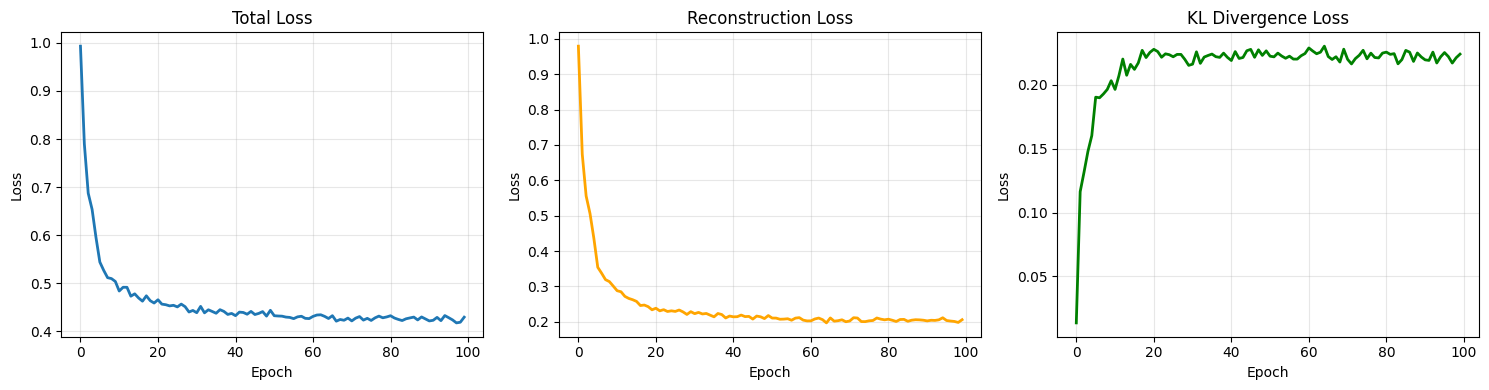

In [26]:
# Plot training losses
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(trainer.history['total_loss'], linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(trainer.history['recon_loss'], linewidth=2, color='orange')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(trainer.history['kl_loss'], linewidth=2, color='green')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/04_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Evaluate on Test Set

In [27]:
# Evaluate on test set
vae.eval()
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    recon_x, mu, logvar, z = vae(X_test_tensor)
    recon_loss = ((recon_x - X_test_tensor) ** 2).mean().item()

print(f"Test Reconstruction Loss: {recon_loss:.6f}")
print(f"Latent space shape: {z.shape}")

Test Reconstruction Loss: 0.259197
Latent space shape: torch.Size([401, 10])


## 6. Save Model

In [28]:
# Save model
torch.save({
    'model_state': vae.state_dict(),
    'config': config,
    'scaler': scaler
}, '../results/vae_model.pth')

print("Model saved to ../results/vae_model.pth")

Model saved to ../results/vae_model.pth
